##### Copyright 2021 The TensorFlow Authors.

In [1]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://www.tensorflow.org/tutorials/audio/transfer_learning_audio"><img src="https://www.tensorflow.org/images/tf_logo_32px.png" />View on TensorFlow.org</a>
  </td>
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/audio/transfer_learning_audio.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/tensorflow/docs/blob/master/site/en/tutorials/audio/transfer_learning_audio.ipynb"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />View on GitHub</a>
  </td>
  <td>
    <a href="https://storage.googleapis.com/tensorflow_docs/docs/site/en/tutorials/audio/transfer_learning_audio.ipynb"><img src="https://www.tensorflow.org/images/download_logo_32px.png" />Download notebook</a>
  </td>
  <td>
    <a href="https://tfhub.dev/google/yamnet/1"><img src="https://www.tensorflow.org/images/hub_logo_32px.png" />See TF Hub model</a>
  </td>
</table>

# Transfer learning with YAMNet for environmental sound classification

[YAMNet](https://tfhub.dev/google/yamnet/1) is a pre-trained deep neural network that can predict audio events from [521 classes](https://github.com/tensorflow/models/blob/master/research/audioset/yamnet/yamnet_class_map.csv), such as laughter, barking, or a siren. 

 In this tutorial you will learn how to:

- Load and use the YAMNet model for inference.
- Build a new model using the YAMNet embeddings to classify cat and dog sounds.
- Evaluate and export your model.


## Import TensorFlow and other libraries


Start by installing [TensorFlow I/O](https://www.tensorflow.org/io), which will make it easier for you to load audio files off disk.

In [2]:
import pandas as pd
import plotly.express as px
import os

from IPython import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_io as tfio

import params as yamnet_params
import yamnet as yamnet_model

## About YAMNet

[YAMNet](https://github.com/tensorflow/models/tree/master/research/audioset/yamnet) is a pre-trained neural network that employs the [MobileNetV1](https://arxiv.org/abs/1704.04861) depthwise-separable convolution architecture. It can use an audio waveform as input and make independent predictions for each of the 521 audio events from the [AudioSet](http://g.co/audioset) corpus.

Internally, the model extracts "frames" from the audio signal and processes batches of these frames. This version of the model uses frames that are 0.96 second long and extracts one frame every 0.48 seconds .

The model accepts a 1-D float32 Tensor or NumPy array containing a waveform of arbitrary length, represented as single-channel (mono) 16 kHz samples in the range `[-1.0, +1.0]`. This tutorial contains code to help you convert WAV files into the supported format.

The model returns 3 outputs, including the class scores, embeddings (which you will use for transfer learning), and the log mel [spectrogram](https://www.tensorflow.org/tutorials/audio/simple_audio#spectrogram). You can find more details [here](https://tfhub.dev/google/yamnet/1).

One specific use of YAMNet is as a high-level feature extractor - the 1,024-dimensional embedding output. You will use the base (YAMNet) model's input features and feed them into your shallower model consisting of one hidden `tf.keras.layers.Dense` layer. Then, you will train the network on a small amount of data for audio classification _without_ requiring a lot of labeled data and training end-to-end. (This is similar to [transfer learning for image classification with TensorFlow Hub](https://www.tensorflow.org/tutorials/images/transfer_learning_with_hub) for more information.)

First, you will test the model and see the results of classifying audio. You will then construct the data pre-processing pipeline.

### Loading YAMNet from TensorFlow Hub

You are going to use a pre-trained YAMNet from [Tensorflow Hub](https://tfhub.dev/) to extract the embeddings from the sound files.

Loading a model from TensorFlow Hub is straightforward: choose the model, copy its URL, and use the `load` function.

Note: to read the documentation of the model, use the model URL in your browser.

In [3]:
params = yamnet_params.Params()
yamnet = yamnet_model.yamnet_frames_model(params)
yamnet.load_weights('yamnet.h5')
yamnet_classes = yamnet_model.class_names('yamnet_class_map.csv')

In [4]:
# testing if everything is working:

# print the model summary
yamnet.summary()

Model: "yamnet_frames"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None,)]            0           []                               
                                                                                                  
 tf.compat.v1.shape (TFOpLambda  (1,)                0           ['input_1[0][0]']                
 )                                                                                                
                                                                                                  
 tf.__operators__.getitem (Slic  ()                  0           ['tf.compat.v1.shape[0][0]']     
 ingOpLambda)                                                                                     
                                                                                      

In [5]:
# yamnet classes
print(yamnet_classes)

['Speech' 'Child speech, kid speaking' 'Conversation'
 'Narration, monologue' 'Babbling' 'Speech synthesizer' 'Shout' 'Bellow'
 'Whoop' 'Yell' 'Children shouting' 'Screaming' 'Whispering' 'Laughter'
 'Baby laughter' 'Giggle' 'Snicker' 'Belly laugh' 'Chuckle, chortle'
 'Crying, sobbing' 'Baby cry, infant cry' 'Whimper' 'Wail, moan' 'Sigh'
 'Singing' 'Choir' 'Yodeling' 'Chant' 'Mantra' 'Child singing'
 'Synthetic singing' 'Rapping' 'Humming' 'Groan' 'Grunt' 'Whistling'
 'Breathing' 'Wheeze' 'Snoring' 'Gasp' 'Pant' 'Snort' 'Cough'
 'Throat clearing' 'Sneeze' 'Sniff' 'Run' 'Shuffle' 'Walk, footsteps'
 'Chewing, mastication' 'Biting' 'Gargling' 'Stomach rumble'
 'Burping, eructation' 'Hiccup' 'Fart' 'Hands' 'Finger snapping'
 'Clapping' 'Heart sounds, heartbeat' 'Heart murmur' 'Cheering' 'Applause'
 'Chatter' 'Crowd' 'Hubbub, speech noise, speech babble'
 'Children playing' 'Animal' 'Domestic animals, pets' 'Dog' 'Bark' 'Yip'
 'Howl' 'Bow-wow' 'Growling' 'Whimper (dog)' 'Cat' 'Purr' 'Meow' 

In [6]:
# testing audio file
audio_file = r"D:\AUDIOSET_STRONG\train_16k\0x1a000f8db5451d30.wav"
print(audio_file)

D:\AUDIOSET_STRONG\train_16k\0x1a000f8db5451d30.wav


In [7]:
@tf.function
def load_wav_16k_mono(filename):
    """ Load a WAV file, convert it to a float tensor, resample to 16 kHz single-channel audio. """
    file_contents = tf.io.read_file(filename)
    wav, sample_rate = tf.audio.decode_wav(
          file_contents,
          desired_channels=1)
    wav = tf.squeeze(wav, axis=-1)
    sample_rate = tf.cast(sample_rate, dtype=tf.int64)
    wav = tfio.audio.resample(wav, rate_in=sample_rate, rate_out=16000)
    return wav

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


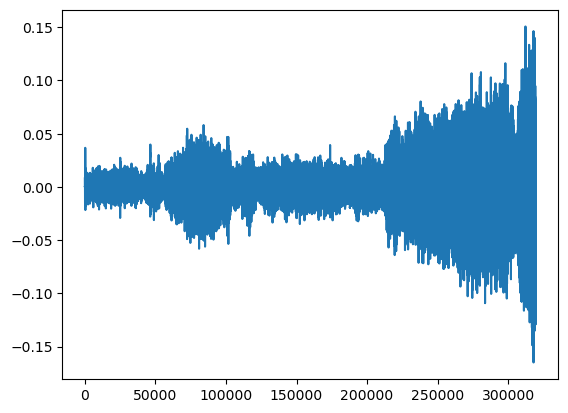

In [8]:
# run the model on the test file
testing_wav_data = load_wav_16k_mono(audio_file)

_ = plt.plot(testing_wav_data)

# Play the audio file.
display.Audio(testing_wav_data, rate=16000)

In [9]:
# print the class names
for i in range(len(yamnet_classes)):
  print(f'{i}: {yamnet_classes[i]}')


0: Speech
1: Child speech, kid speaking
2: Conversation
3: Narration, monologue
4: Babbling
5: Speech synthesizer
6: Shout
7: Bellow
8: Whoop
9: Yell
10: Children shouting
11: Screaming
12: Whispering
13: Laughter
14: Baby laughter
15: Giggle
16: Snicker
17: Belly laugh
18: Chuckle, chortle
19: Crying, sobbing
20: Baby cry, infant cry
21: Whimper
22: Wail, moan
23: Sigh
24: Singing
25: Choir
26: Yodeling
27: Chant
28: Mantra
29: Child singing
30: Synthetic singing
31: Rapping
32: Humming
33: Groan
34: Grunt
35: Whistling
36: Breathing
37: Wheeze
38: Snoring
39: Gasp
40: Pant
41: Snort
42: Cough
43: Throat clearing
44: Sneeze
45: Sniff
46: Run
47: Shuffle
48: Walk, footsteps
49: Chewing, mastication
50: Biting
51: Gargling
52: Stomach rumble
53: Burping, eructation
54: Hiccup
55: Fart
56: Hands
57: Finger snapping
58: Clapping
59: Heart sounds, heartbeat
60: Heart murmur
61: Cheering
62: Applause
63: Chatter
64: Crowd
65: Hubbub, speech noise, speech babble
66: Children playing
67: Anim

In [10]:
# run the model, check the output.
scores, embeddings, spectrogram = yamnet(testing_wav_data)
class_scores = tf.reduce_mean(scores, axis=0)
top_class = tf.argmax(class_scores)
inferred_class = yamnet_classes[top_class]

print(f'The main sound is: {inferred_class}')
print(f'The embeddings shape: {embeddings.shape}')

The main sound is: Vehicle
The embeddings shape: (41, 1024)


### train

In [11]:
base_data_path = r"D:\AUDIOSET_STRONG"

train_path = r"train_16k"
eval_path = r"eval_16k"

train_csv = r"audioset_train_strong_filt_downloaded.csv"

pd_train = pd.read_csv(os.path.join(base_data_path, train_csv))
pd_train.head()

,Unnamed: 0,segment_id,start_time_seconds,end_time_seconds,label,duration,clip_id,filename,index,mid,display_name
0,0,b0RFKhbpFJA_30000,0.000,10.000,/m/03m9d0z,10.000,0x7b99cd732dabfef0,0x7b99cd732dabfef0.wav,277,/m/03m9d0z,Wind
1,152,ZvAdd4Jb1xA_30000,0.000,10.000,/m/03m9d0z,10.000,-0x6da6a8a6c54e3ad,-0x6da6a8a6c54e3ad.wav,277,/m/03m9d0z,Wind
2,169,sWdJR9dInhw_19000,0.000,9.803,/m/03m9d0z,9.803,-0x52b316ded52fb65e,-0x52b316ded52fb65e.wav,277,/m/03m9d0z,Wind
3,250,3zOfKHtXxws_30000,0.000,10.000,/m/03m9d0z,10.000,0x4ea20c5a7d1cf994,0x4ea20c5a7d1cf994.wav,277,/m/03m9d0z,Wind
4,314,0r4zxu38gt0_0,0.083,10.000,/m/03m9d0z,9.917,0x5a0670380b88cad7,0x5a0670380b88cad7.wav,277,/m/03m9d0z,Wind


In [12]:
# remove label columns
pd_train = pd_train.drop(columns=['label', 'index', 'Unnamed: 0', 'clip_id'])

In [13]:
pd_train.head()

,segment_id,start_time_seconds,end_time_seconds,duration,clip_id,filename,mid,display_name
0,b0RFKhbpFJA_30000,0.000,10.000,10.000,0x7b99cd732dabfef0,0x7b99cd732dabfef0.wav,/m/03m9d0z,Wind
1,ZvAdd4Jb1xA_30000,0.000,10.000,10.000,-0x6da6a8a6c54e3ad,-0x6da6a8a6c54e3ad.wav,/m/03m9d0z,Wind
2,sWdJR9dInhw_19000,0.000,9.803,9.803,-0x52b316ded52fb65e,-0x52b316ded52fb65e.wav,/m/03m9d0z,Wind
3,3zOfKHtXxws_30000,0.000,10.000,10.000,0x4ea20c5a7d1cf994,0x4ea20c5a7d1cf994.wav,/m/03m9d0z,Wind
4,0r4zxu38gt0_0,0.083,10.000,9.917,0x5a0670380b88cad7,0x5a0670380b88cad7.wav,/m/03m9d0z,Wind


In [15]:
# check if the audio files exist
total_files = len(pd_train)
print("Checking files in: ", base_data_path)
print("\nTotal files: ", total_files)
print()

for index, row in pd_train.iterrows():
    file_path = row['filename']
    
    # join the path and filename
    file_path = os.path.join(base_data_path, train_path, file_path)
    
    if not os.path.isfile(file_path):
        print("file not found: ", file_path)
        pd_train.drop(index, inplace=True)

total_files_after = len(pd_train)
print("\nTotal files after checking: ", total_files_after)

total_files_removed = total_files - total_files_after
print("\nTotal files removed: ", total_files_removed)

Checking files in:  D:\AUDIOSET_STRONG

Total files:  141264

file not found:  D:\AUDIOSET_STRONG\train_16k\0x74b2cac4f03e01cb.wav
file not found:  D:\AUDIOSET_STRONG\train_16k\-0x513a3c9139d960a4.wav
file not found:  D:\AUDIOSET_STRONG\train_16k\-0x392001de53e09c77.wav
file not found:  D:\AUDIOSET_STRONG\train_16k\-0x7dbeae7cce955e24.wav
file not found:  D:\AUDIOSET_STRONG\train_16k\-0x354dd3237cef2857.wav
file not found:  D:\AUDIOSET_STRONG\train_16k\-0x1717836c3b156afb.wav
file not found:  D:\AUDIOSET_STRONG\train_16k\0x5f5d0798106e7ca9.wav
file not found:  D:\AUDIOSET_STRONG\train_16k\0x5a612109bb83d08c.wav
file not found:  D:\AUDIOSET_STRONG\train_16k\0x68c6d100346464dc.wav
file not found:  D:\AUDIOSET_STRONG\train_16k\0x2db64462b50a4bb2.wav
file not found:  D:\AUDIOSET_STRONG\train_16k\-0x18855ee9f3b087ad.wav
file not found:  D:\AUDIOSET_STRONG\train_16k\0x7b8ac9f3f024ac84.wav
file not found:  D:\AUDIOSET_STRONG\train_16k\-0x2701e62859e82b44.wav
file not found:  D:\AUDIOSET_STRON

In [16]:
print(len(pd_train))

138212


In [17]:
pd_train.head()

,segment_id,start_time_seconds,end_time_seconds,duration,clip_id,filename,mid,display_name
0,b0RFKhbpFJA_30000,0.000,10.000,10.000,0x7b99cd732dabfef0,0x7b99cd732dabfef0.wav,/m/03m9d0z,Wind
1,ZvAdd4Jb1xA_30000,0.000,10.000,10.000,-0x6da6a8a6c54e3ad,-0x6da6a8a6c54e3ad.wav,/m/03m9d0z,Wind
2,sWdJR9dInhw_19000,0.000,9.803,9.803,-0x52b316ded52fb65e,-0x52b316ded52fb65e.wav,/m/03m9d0z,Wind
3,3zOfKHtXxws_30000,0.000,10.000,10.000,0x4ea20c5a7d1cf994,0x4ea20c5a7d1cf994.wav,/m/03m9d0z,Wind
4,0r4zxu38gt0_0,0.083,10.000,9.917,0x5a0670380b88cad7,0x5a0670380b88cad7.wav,/m/03m9d0z,Wind


In [18]:
# save the new csv
pd_train.to_csv(os.path.join(base_data_path, "audioset_66_classes_clean.csv"))

In [20]:
# label the folds for evaluation.
# 1. get the unique labels
labels = pd_train['display_name'].unique()
# print(labels)
print("Total labels: ", len(labels))

# 2. create a dictionary with the labels
label_dict = {}
for index, label in enumerate(labels):
    label_dict[label] = index
    
print(label_dict)

# count the number of files per label
label_count = {}
for index, row in pd_train.iterrows():
    label = row['display_name']
    if label in label_count:
        label_count[label] += 1
    else:
        label_count[label] = 1
        
print(f"\nThis is the count for labels:\n {label_count}")

Total labels:  64
{'Wind': 0, 'Power tool': 1, 'Shout': 2, 'Mechanisms': 3, 'Bark': 4, 'Conversation': 5, 'Speech': 6, 'Dog': 7, 'Bird vocalization, bird call, bird song': 8, 'Bird': 9, 'Wind noise (microphone)': 10, 'Chirp, tweet': 11, 'Engine starting': 12, 'Hubbub, speech noise, speech babble': 13, 'Motor vehicle (road)': 14, 'Car': 15, 'Car alarm': 16, 'Medium engine (mid frequency)': 17, 'Water': 18, 'Rain': 19, 'Alarm': 20, 'Ocean': 21, 'Ship': 22, 'Light engine (high frequency)': 23, 'Tools': 24, 'Truck': 25, 'Thump, thud': 26, 'Traffic noise, roadway noise': 27, 'Screaming': 28, 'Motorcycle': 29, 'Squeak': 30, 'Reversing beeps': 31, 'Ambulance (siren)': 32, 'Clang': 33, 'Engine': 34, 'Waves, surf': 35, 'Whistle': 36, 'Siren': 37, 'Stream': 38, 'Mechanical fan': 39, 'Air horn, truck horn': 40, 'Rain on surface': 41, 'Engine knocking': 42, 'Car passing by': 43, 'Air brake': 44, 'Vehicle horn, car horn, honking': 45, 'Emergency vehicle': 46, 'Rumble': 47, 'Thunk': 48, 'Buzzer': 49

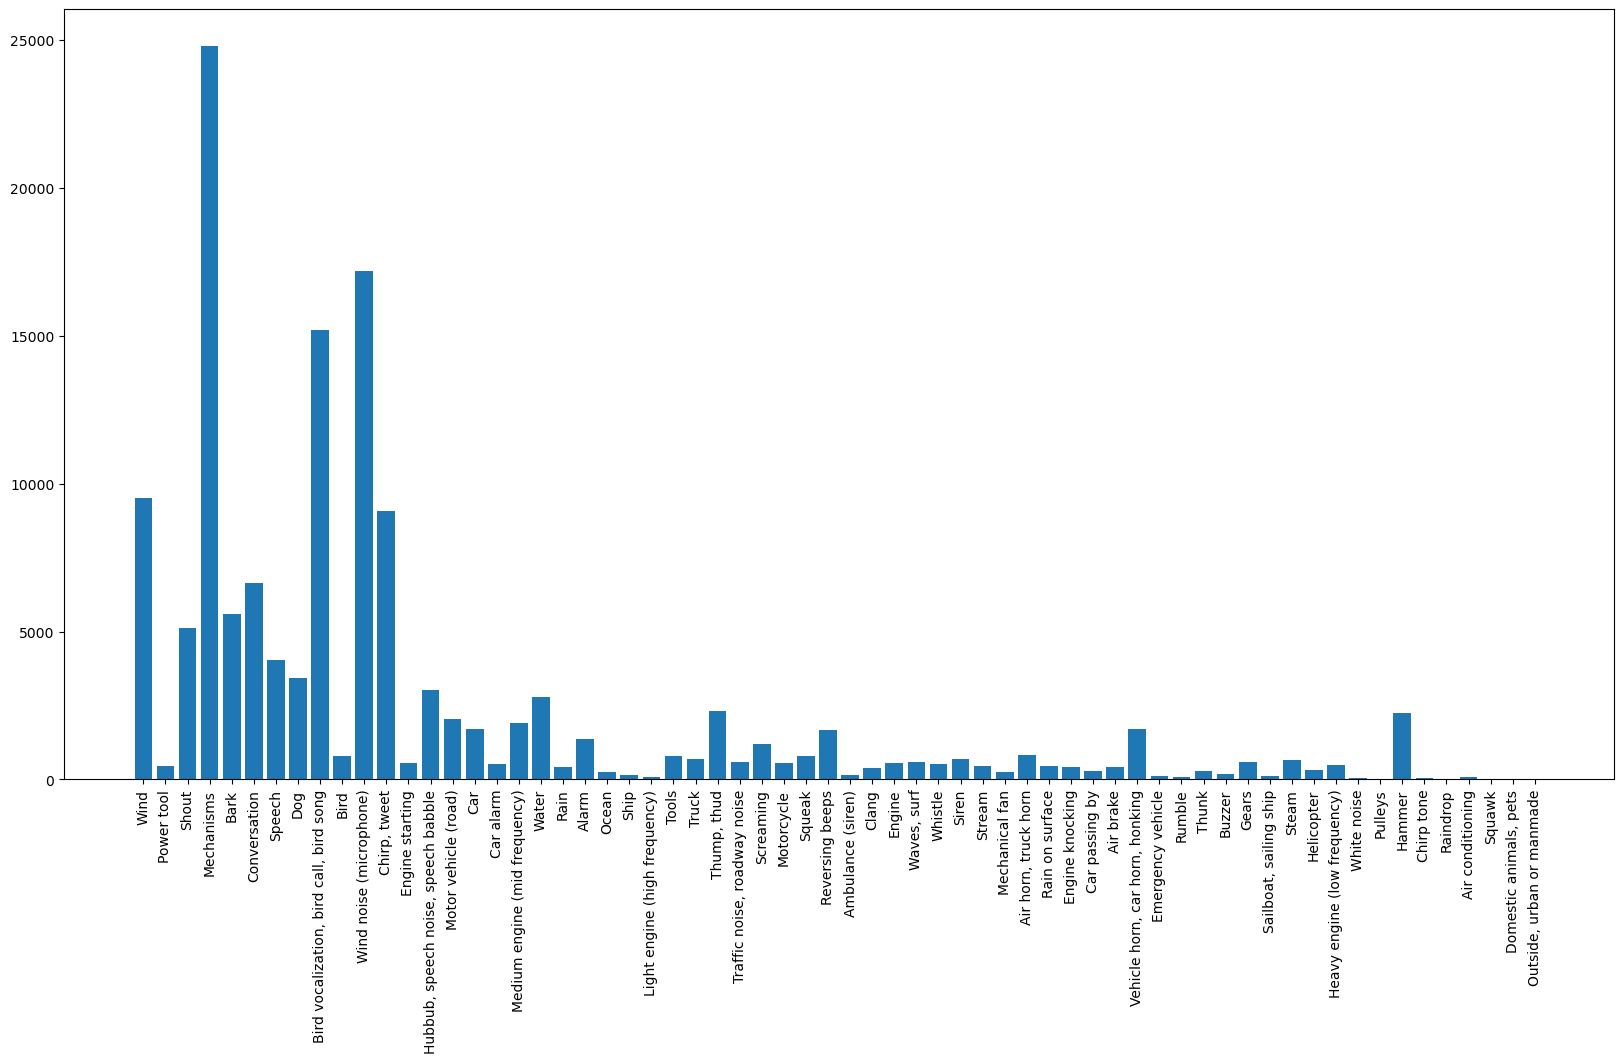

In [21]:
# plot the label count
plt.figure(figsize=(20,10))
plt.bar(label_count.keys(), label_count.values())
plt.xticks(rotation=90)
plt.show()

In [22]:
# Calculate label counts
label_count = pd_train['display_name'].value_counts().to_dict()

# Initialize the fold column
pd_train['fold'] = 0

# Assign the folds
for label, count in label_count.items():
    # Calculate the number of samples for each fold
    num_train = int(count * 0.8)
    num_eval = int(count * 0.1)

    # Get indices of the current label
    indices = pd_train[pd_train['display_name'] == label].index

    # Assign fold numbers
    pd_train.loc[indices[:num_train], 'fold'] = 1  # 80% for training
    pd_train.loc[indices[num_train:num_train + num_eval], 'fold'] = 2  # 10% for evaluation
    pd_train.loc[indices[num_train + num_eval:], 'fold'] = 3  # Remaining 10% for testing

# Check the distribution of the folds
fold_distribution = pd_train['fold'].value_counts(normalize=True)

fold_distribution, pd_train.head()

(1    0.799822
 3    0.100368
 2    0.099810
 Name: fold, dtype: float64,
           segment_id  start_time_seconds  end_time_seconds  duration  \
 0  b0RFKhbpFJA_30000               0.000            10.000    10.000   
 1  ZvAdd4Jb1xA_30000               0.000            10.000    10.000   
 2  sWdJR9dInhw_19000               0.000             9.803     9.803   
 3  3zOfKHtXxws_30000               0.000            10.000    10.000   
 4      0r4zxu38gt0_0               0.083            10.000     9.917   
 
                clip_id                 filename         mid display_name  fold  
 0   0x7b99cd732dabfef0   0x7b99cd732dabfef0.wav  /m/03m9d0z         Wind     1  
 1   -0x6da6a8a6c54e3ad   -0x6da6a8a6c54e3ad.wav  /m/03m9d0z         Wind     1  
 2  -0x52b316ded52fb65e  -0x52b316ded52fb65e.wav  /m/03m9d0z         Wind     1  
 3   0x4ea20c5a7d1cf994   0x4ea20c5a7d1cf994.wav  /m/03m9d0z         Wind     1  
 4   0x5a0670380b88cad7   0x5a0670380b88cad7.wav  /m/03m9d0z         Wind   

In [23]:
pd_train

,segment_id,start_time_seconds,end_time_seconds,duration,clip_id,filename,mid,display_name,fold
0,b0RFKhbpFJA_30000,0.000,10.000,10.000,0x7b99cd732dabfef0,0x7b99cd732dabfef0.wav,/m/03m9d0z,Wind,1
1,ZvAdd4Jb1xA_30000,0.000,10.000,10.000,-0x6da6a8a6c54e3ad,-0x6da6a8a6c54e3ad.wav,/m/03m9d0z,Wind,1
2,sWdJR9dInhw_19000,0.000,9.803,9.803,-0x52b316ded52fb65e,-0x52b316ded52fb65e.wav,/m/03m9d0z,Wind,1
3,3zOfKHtXxws_30000,0.000,10.000,10.000,0x4ea20c5a7d1cf994,0x4ea20c5a7d1cf994.wav,/m/03m9d0z,Wind,1
4,0r4zxu38gt0_0,0.083,10.000,9.917,0x5a0670380b88cad7,0x5a0670380b88cad7.wav,/m/03m9d0z,Wind,1
...,...,...,...,...,...,...,...,...,...
141259,pomUWYaREso_20000,0.906,1.984,1.078,0x64108f4c27c01c8f,0x64108f4c27c01c8f.wav,/m/068hy,"Domestic animals, pets",2
141260,pomUWYaREso_20000,3.134,4.094,0.960,0x46642ec89d316ae6,0x46642ec89d316ae6.wav,/m/068hy,"Domestic animals, pets",3
141261,pomUWYaREso_20000,7.898,8.339,0.441,0x1d60034a9896521b,0x1d60034a9896521b.wav,/m/068hy,"Domestic animals, pets",3
141262,pomUWYaREso_20000,9.173,9.740,0.567,-0x6692ad1da5309aa4,-0x6692ad1da5309aa4.wav,/m/068hy,"Domestic animals, pets",3


In [24]:
# save the new csv
pd_train.to_csv(os.path.join(base_data_path, "audioset_66_classes_folds.csv"))

In [27]:
class_counts = pd_train['display_name'].value_counts().reset_index()
class_counts.columns = ['display_name', 'count']

fig = px.treemap(class_counts, 
                 path=['display_name'], 
                 values='count',
                 title='Distribution of Audio Classes in the TRAIN Dataset')

fig.show()

In [25]:
unique_classes = pd_train['display_name'].unique()

equal_value_df = pd.DataFrame({'display_name': unique_classes, 'value': 1})

fig = px.treemap(equal_value_df, 
                 path=['display_name'], 
                 values='value',
                 title='Equal Proportion Treemap of Audio Classes in the TRAIN Dataset')

fig.show()

In [29]:
print(f"These are the in the train dataset: \n\n{pd_train['display_name'].unique()}")

print(f"\nThere are {len(pd_train['display_name'].unique())} classes in the train dataset")

These are the in the train dataset: 

['Wind' 'Power tool' 'Shout' 'Mechanisms' 'Bark' 'Conversation' 'Speech'
 'Dog' 'Bird vocalization, bird call, bird song' 'Bird'
 'Wind noise (microphone)' 'Chirp, tweet' 'Engine starting'
 'Hubbub, speech noise, speech babble' 'Motor vehicle (road)' 'Car'
 'Car alarm' 'Medium engine (mid frequency)' 'Water' 'Rain' 'Alarm'
 'Ocean' 'Ship' 'Light engine (high frequency)' 'Tools' 'Truck'
 'Thump, thud' 'Traffic noise, roadway noise' 'Screaming' 'Motorcycle'
 'Squeak' 'Reversing beeps' 'Ambulance (siren)' 'Clang' 'Engine'
 'Waves, surf' 'Whistle' 'Siren' 'Stream' 'Mechanical fan'
 'Air horn, truck horn' 'Rain on surface' 'Engine knocking'
 'Car passing by' 'Air brake' 'Vehicle horn, car horn, honking'
 'Emergency vehicle' 'Rumble' 'Thunk' 'Buzzer' 'Gears'
 'Sailboat, sailing ship' 'Steam' 'Helicopter'
 'Heavy engine (low frequency)' 'White noise' 'Pulleys' 'Hammer'
 'Chirp tone' 'Raindrop' 'Air conditioning' 'Squawk'
 'Domestic animals, pets' 'Outside

In [30]:
port_66_classes = ['Wind', 'Shout', 'Mechanisms', 'Bark', 'Conversation', 'Speech',
                 'Dog', 'Bird vocalization, bird call, bird song', 'Bird',
                 'Wind noise (microphone)', 'Chirp, tweet', 'Engine starting',
                 'Hubbub, speech noise, speech babble', 'Motor vehicle (road)', 'Car',
                 'Car alarm', 'Medium engine (mid frequency)', 'Water', 'Rain', 'Alarm',
                 'Ocean', 'Ship', 'Light engine (high frequency)', 'Tools', 'Truck',
                 'Thump, thud', 'Traffic noise, roadway noise', 'Screaming', 'Motorcycle',
                 'Squeak', 'Reversing beeps', 'Ambulance (siren)', 'Clang', 'Engine',
                 'Waves, surf', 'Whistle', 'Siren', 'Stream', 'Mechanical fan',
                 'Air horn, truck horn', 'Rain on surface', 'Engine knocking',
                 'Car passing by', 'Air brake', 'Vehicle horn, car horn, honking',
                 'Emergency vehicle', 'Rumble', 'Thunk', 'Buzzer', 'Gears',
                 'Sailboat, sailing ship', 'Steam', 'Helicopter',
                 'Heavy engine (low frequency)', 'White noise', 'Pulleys', 'Hammer',
                 'Chirp tone', 'Raindrop', 'Air conditioning', 'Squawk',
                 'Domestic animals, pets', 'Outside, urban or manmade']

port_66_classes_to_id = {'Wind':0, 'Shout':1, 'Mechanisms':2, 'Bark':3, 'Conversation':4, 'Speech':5,
                 'Dog':6, 'Bird vocalization, bird call, bird song':7, 'Bird':8,
                 'Wind noise (microphone)':9, 'Chirp, tweet':10, 'Engine starting':11,
                 'Hubbub, speech noise, speech babble':12, 'Motor vehicle (road)':13, 'Car':14,
                 'Car alarm':15, 'Medium engine (mid frequency)':16, 'Water':17, 'Rain':18, 'Alarm':19,
                 'Ocean':20, 'Ship':21, 'Light engine (high frequency)':22, 'Tools':23, 'Truck':24,
                 'Thump, thud':25, 'Traffic noise, roadway noise':26, 'Screaming':27, 'Motorcycle':28,
                 'Squeak':29, 'Reversing beeps':30, 'Ambulance (siren)':31, 'Clang':32, 'Engine':33,
                 'Waves, surf':34, 'Whistle':35, 'Siren':36, 'Stream':37, 'Mechanical fan':38,
                 'Air horn, truck horn':39, 'Rain on surface':40, 'Engine knocking':41,
                 'Car passing by':42, 'Air brake':43, 'Vehicle horn, car horn, honking':44,
                 'Emergency vehicle':45, 'Rumble':46, 'Thunk':47, 'Buzzer':48, 'Gears':49,
                 'Sailboat, sailing ship':50, 'Steam':51, 'Helicopter':52,
                 'Heavy engine (low frequency)':53, 'White noise':54, 'Pulleys':55, 'Hammer':56,
                 'Chirp tone':57, 'Raindrop':58, 'Air conditioning':59, 'Squawk':60,
                 'Domestic animals, pets':61, 'Outside, urban or manmade':62}

In [44]:
filtered_pd = pd_train[pd_train.display_name.isin(port_66_classes)]

class_id = filtered_pd['display_name'].apply(lambda name: port_66_classes_to_id[name])
filtered_pd = filtered_pd.assign(target=class_id)

full_path = filtered_pd['filename'].apply(lambda name: os.path.join(base_data_path, train_path, name))
filtered_pd = filtered_pd.assign(filename=full_path)

# rename the column display_name to category
filtered_pd.rename(columns={'display_name': 'category'}, inplace=True)

# move column order: filename	fold	target	category
filtered_pd = filtered_pd[['filename', 'fold', 'target', 'category', 'segment_id', 'start_time_seconds', 'end_time_seconds', 'duration', 'clip_id']]

filtered_pd.head(10)

,filename,fold,target,category,segment_id,start_time_seconds,end_time_seconds,duration,clip_id
0,D:\AUDIOSET_STRONG\train_16k\0x7b99cd732dabfef...,1,0,Wind,b0RFKhbpFJA_30000,0.000,10.000,10.000,0x7b99cd732dabfef0
1,D:\AUDIOSET_STRONG\train_16k\-0x6da6a8a6c54e3a...,1,0,Wind,ZvAdd4Jb1xA_30000,0.000,10.000,10.000,-0x6da6a8a6c54e3ad
2,D:\AUDIOSET_STRONG\train_16k\-0x52b316ded52fb6...,1,0,Wind,sWdJR9dInhw_19000,0.000,9.803,9.803,-0x52b316ded52fb65e
3,D:\AUDIOSET_STRONG\train_16k\0x4ea20c5a7d1cf99...,1,0,Wind,3zOfKHtXxws_30000,0.000,10.000,10.000,0x4ea20c5a7d1cf994
4,D:\AUDIOSET_STRONG\train_16k\0x5a0670380b88cad...,1,0,Wind,0r4zxu38gt0_0,0.083,10.000,9.917,0x5a0670380b88cad7
5,D:\AUDIOSET_STRONG\train_16k\-0x1b9ae0c48b3ac1...,1,0,Wind,gICZlgNZuzo_370000,0.000,10.000,10.000,-0x1b9ae0c48b3ac195
6,D:\AUDIOSET_STRONG\train_16k\-0x2634df9a06ed3f...,1,0,Wind,tstg4ljERAY_60000,0.000,10.000,10.000,-0x2634df9a06ed3fb1
7,D:\AUDIOSET_STRONG\train_16k\0x289574d47fdd8bb...,1,0,Wind,YdFfhvxPe2g_70000,0.000,9.465,9.465,0x289574d47fdd8bbb
8,D:\AUDIOSET_STRONG\train_16k\0x5eb0be1f2cf2551...,1,0,Wind,4XaFQxTLkfI_30000,0.008,10.000,9.992,0x5eb0be1f2cf2551d
9,D:\AUDIOSET_STRONG\train_16k\-0xa064f0b3d377ca...,1,0,Wind,CwQKT8z0OsI_30000,0.000,10.000,10.000,-0xa064f0b3d377ca4


In [46]:
for index, row in filtered_pd.iterrows():
    # check if the file exists
    if not os.path.isfile(row['filename']):
        print("file not found: ", row['filename'])
        filtered_pd.drop(index, inplace=True)

In [47]:
filtered_pd.head(10)

,filename,fold,target,category,segment_id,start_time_seconds,end_time_seconds,duration,clip_id
0,D:\AUDIOSET_STRONG\train_16k\0x7b99cd732dabfef...,1,0,Wind,b0RFKhbpFJA_30000,0.000,10.000,10.000,0x7b99cd732dabfef0
1,D:\AUDIOSET_STRONG\train_16k\-0x6da6a8a6c54e3a...,1,0,Wind,ZvAdd4Jb1xA_30000,0.000,10.000,10.000,-0x6da6a8a6c54e3ad
2,D:\AUDIOSET_STRONG\train_16k\-0x52b316ded52fb6...,1,0,Wind,sWdJR9dInhw_19000,0.000,9.803,9.803,-0x52b316ded52fb65e
3,D:\AUDIOSET_STRONG\train_16k\0x4ea20c5a7d1cf99...,1,0,Wind,3zOfKHtXxws_30000,0.000,10.000,10.000,0x4ea20c5a7d1cf994
4,D:\AUDIOSET_STRONG\train_16k\0x5a0670380b88cad...,1,0,Wind,0r4zxu38gt0_0,0.083,10.000,9.917,0x5a0670380b88cad7
5,D:\AUDIOSET_STRONG\train_16k\-0x1b9ae0c48b3ac1...,1,0,Wind,gICZlgNZuzo_370000,0.000,10.000,10.000,-0x1b9ae0c48b3ac195
6,D:\AUDIOSET_STRONG\train_16k\-0x2634df9a06ed3f...,1,0,Wind,tstg4ljERAY_60000,0.000,10.000,10.000,-0x2634df9a06ed3fb1
7,D:\AUDIOSET_STRONG\train_16k\0x289574d47fdd8bb...,1,0,Wind,YdFfhvxPe2g_70000,0.000,9.465,9.465,0x289574d47fdd8bbb
8,D:\AUDIOSET_STRONG\train_16k\0x5eb0be1f2cf2551...,1,0,Wind,4XaFQxTLkfI_30000,0.008,10.000,9.992,0x5eb0be1f2cf2551d
9,D:\AUDIOSET_STRONG\train_16k\-0xa064f0b3d377ca...,1,0,Wind,CwQKT8z0OsI_30000,0.000,10.000,10.000,-0xa064f0b3d377ca4


In [48]:
print(len(filtered_pd))

137759


In [49]:
filenames = filtered_pd['filename']
targets = filtered_pd['target']
folds = filtered_pd['fold']

main_ds = tf.data.Dataset.from_tensor_slices((filenames, targets, folds))
main_ds.element_spec

(TensorSpec(shape=(), dtype=tf.string, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None))

In [50]:
def load_wav_for_map(filename, label, fold):
  return load_wav_16k_mono(filename), label, fold

main_ds = main_ds.map(load_wav_for_map)
main_ds.element_spec

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


(TensorSpec(shape=<unknown>, dtype=tf.float32, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None))

In [52]:
# applies the embedding extraction model to a wav data
def extract_embedding(wav_data, label, fold):
  ''' run YAMNet to extract embedding from the wav data '''
  scores, embeddings, spectrogram = yamnet(testing_wav_data)
  num_embeddings = tf.shape(embeddings)[0]
  return (embeddings,
            tf.repeat(label, num_embeddings),
            tf.repeat(fold, num_embeddings))

# extract embedding
main_ds = main_ds.map(extract_embedding).unbatch()
main_ds.element_spec

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


(TensorSpec(shape=(1024,), dtype=tf.float32, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None))

In [53]:
# split the dataset into train, eval and test
cached_ds = main_ds.cache()
train_ds = cached_ds.filter(lambda embedding, label, fold: fold < 3)
val_ds = cached_ds.filter(lambda embedding, label, fold: fold == 2)
test_ds = cached_ds.filter(lambda embedding, label, fold: fold == 3)

# remove the fold column
remove_fold = lambda embedding, label, fold: (embedding, label)

train_ds = train_ds.map(remove_fold)
val_ds = val_ds.map(remove_fold)
test_ds = test_ds.map(remove_fold)

# shuffle the train dataset
# train_ds = train_ds.shuffle(100, reshuffle_each_iteration=True) # reshuffle_each_iteration=True
train_ds = train_ds.cache().shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.cache().batch(32).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.cache().batch(32).prefetch(tf.data.AUTOTUNE)

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set

In [57]:
# create the model
port_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1024), dtype=tf.float32, name='input_embedding'),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(len(port_66_classes), activation='softmax')
], name='audioset_port_classifier')

port_model.summary()

Model: "audioset_port_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_7 (Dense)             (None, 512)               524800    
                                                                 
 dense_8 (Dense)             (None, 256)               131328    
                                                                 
 dense_9 (Dense)             (None, 63)                16191     
                                                                 
Total params: 672,319
Trainable params: 672,319
Non-trainable params: 0
_________________________________________________________________


In [58]:
port_model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                 optimizer="adam",
                 metrics=['accuracy'])

callback = tf.keras.callbacks.EarlyStopping(monitor='loss',
                                            patience=3,
                                            restore_best_weights=True)

In [59]:
history = port_model.fit(train_ds,
                       epochs=20,
                       validation_data=val_ds,
                       callbacks=callback)

Epoch 1/20
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


c:\Users\GIS2\.conda\envs\inference\lib\site-packages\keras\backend.py:5586: UserWarning:

"`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?



  16833/Unknown - 2545s 151ms/step - loss: 0.0043 - accuracy: 0.9986

## Create your model

You did most of the work!
Next, define a very simple [Sequential](https://www.tensorflow.org/guide/keras/sequential_model) model with one hidden layer and two outputs to recognize cats and dogs from sounds.


In [ ]:
my_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1024), dtype=tf.float32,
                          name='input_embedding'),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(len(my_classes))
], name='my_model')

my_model.summary()

Model: "my_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 512)               524800    
                                                                 
 dense_1 (Dense)             (None, 2)                 1026      
                                                                 
Total params: 525,826
Trainable params: 525,826
Non-trainable params: 0
_________________________________________________________________


In [ ]:
my_model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                 optimizer="adam",
                 metrics=['accuracy'])

callback = tf.keras.callbacks.EarlyStopping(monitor='loss',
                                            patience=3,
                                            restore_best_weights=True)

In [ ]:
history = my_model.fit(train_ds,
                       epochs=20,
                       validation_data=val_ds,
                       callbacks=callback)

Epoch 1/20
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
     11/Unknown - 4s 5ms/step - loss: 1.2560 - accuracy: 0.8011WARNING:tensorflow:AutoGraph could not transform <function Model.make_test_function.<locals>.test_function at 0x0000020669F59F78> and will run it as-is.
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
15/15 [==============================] - 4s 28ms/step - loss: 1.1860 - accuracy: 0.8208 - val_loss: 0.9937 - val_accuracy: 0.8687
Epoch 2/20
15/15 [==============================] - 0s 6ms/step - loss: 0.3060 - accuracy: 0.8833 - val_loss: 0.4503 - val_accuracy: 0.8813
Epoch 3/20
15/15 [==============================] - 0s 6ms/step - loss: 0.2765 - accuracy: 0.9021 - val_loss: 0.2442 - val_accuracy: 0.8813
Epoch 4/20
15/15 [==============================] - 0s 6ms/step - loss: 0.2239 - accuracy: 0.9271 - val_loss: 0.2930 - val_accuracy: 0.9125
Epoch 5/20
15/15 [==============================] - 0s 6ms/step - loss: 0.2643 - accuracy: 0.9042 - val_loss: 0.2190 - val_accuracy: 0.9187

## Creating the AAC model for the 66 classes

Next, define a very simple [Sequential](https://www.tensorflow.org/guide/keras/sequential_model) model with one hidden layer and two outputs to recognize cats and dogs from sounds.


In [ ]:
aac_66_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1024), dtype=tf.float32,
                          name='input_embedding'),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(len(my_66_classes))
], name='aac_66_model')

aac_66_model.summary()

Model: "aac_66_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 512)               524800    
                                                                 
 dense_3 (Dense)             (None, 63)                32319     
                                                                 
Total params: 557,119
Trainable params: 557,119
Non-trainable params: 0
_________________________________________________________________


In [ ]:
aac_66_model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                    optimizer="adam",
                    metrics=['accuracy'])

callback_aac_66 = tf.keras.callbacks.EarlyStopping(monitor='loss',
                                            patience=3,
                                            restore_best_weights=True)

In [ ]:
history = aac_66_model.fit(train_ds_aac,
                          epochs=20,
                          validation_data=val_ds_aac,
                          callbacks=callback_aac_66)

Epoch 1/20


63/63 [==============================] - 1s 10ms/step - loss: 0.2179 - accuracy: 0.9840 - val_loss: 8.5142e-06 - val_accuracy: 1.0000
Epoch 2/20


63/63 [==============================] - 0s 866us/step - loss: 0.0000e+00 - accuracy: 0.0000e+00


Let's run the `evaluate` method on the test data just to be sure there's no overfitting.

In [ ]:
loss, accuracy = my_model.evaluate(test_ds)

print("Loss: ", loss)
print("Accuracy: ", accuracy)

5/5 [==============================] - 0s 2ms/step - loss: 0.5052 - accuracy: 0.8125
Loss:  0.5051699876785278
Accuracy:  0.8125


You did it!

### Evaluate

In [ ]:
loss_aac_66, accuracy_aac_66 = aac_66_model.evaluate(test_ds_aac)

print("Loss: ", loss_aac_66)
print("Accuracy: ", accuracy_aac_66)

     68/Unknown - 16s 109ms/step - loss: 7.8121e-06 - accuracy: 1.0000

2024-01-05 12:23:30.569676: W tensorflow/core/framework/op_kernel.cc:1830] OP_REQUIRES failed at whole_file_read_ops.cc:114 : NOT_FOUND: /media/santiago/AAC_Deep_Learning/AUDIOSET_STRONG/train_16k/0x74b2cac4f03e01cb.wav; No such file or directory


     80/Unknown - 18s 110ms/step - loss: 1.0075e-05 - accuracy: 1.0000

NotFoundError: Graph execution error:

/media/santiago/AAC_Deep_Learning/AUDIOSET_STRONG/train_16k/0x74b2cac4f03e01cb.wav; No such file or directory
	 [[{{node ReadFile}}]]
	 [[IteratorGetNext]] [Op:__inference_test_function_68807]

## Test your model

Next, try your model on the embedding from the previous test using YAMNet only.


In [ ]:
scores, embeddings, spectrogram = yamnet_model(testing_wav_data)
result = my_model(embeddings).numpy()

inferred_class = my_classes[result.mean(axis=0).argmax()]
print(f'The main sound is: {inferred_class}')

The main sound is: cat


## Save a model that can directly take a WAV file as input

Your model works when you give it the embeddings as input.

In a real-world scenario, you'll want to use audio data as a direct input.

To do that, you will combine YAMNet with your model into a single model that you can export for other applications.

To make it easier to use the model's result, the final layer will be a `reduce_mean` operation. When using this model for serving (which you will learn about later in the tutorial), you will need the name of the final layer. If you don't define one, TensorFlow will auto-define an incremental one that makes it hard to test, as it will keep changing every time you train the model. When using a raw TensorFlow operation, you can't assign a name to it. To address this issue, you'll create a custom layer that applies `reduce_mean` and call it `'classifier'`.


In [ ]:
class ReduceMeanLayer(tf.keras.layers.Layer):
  def __init__(self, axis=0, **kwargs):
    super(ReduceMeanLayer, self).__init__(**kwargs)
    self.axis = axis

  def call(self, input):
    return tf.math.reduce_mean(input, axis=self.axis)

In [ ]:
saved_model_path = './dogs_and_cats_yamnet'

input_segment = tf.keras.layers.Input(shape=(), dtype=tf.float32, name='audio')
embedding_extraction_layer = hub.KerasLayer(yamnet_model_handle,
                                            trainable=False, name='yamnet')
_, embeddings_output, _ = embedding_extraction_layer(input_segment)
serving_outputs = my_model(embeddings_output)
serving_outputs = ReduceMeanLayer(axis=0, name='classifier')(serving_outputs)
serving_model = tf.keras.Model(input_segment, serving_outputs)
serving_model.save(saved_model_path, include_optimizer=False)

INFO:tensorflow:Assets written to: ./dogs_and_cats_yamnet/assets


INFO:tensorflow:Assets written to: ./dogs_and_cats_yamnet/assets


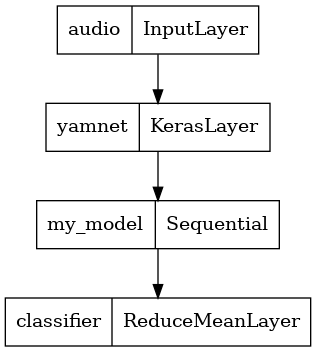

In [ ]:
tf.keras.utils.plot_model(serving_model)

Load your saved model to verify that it works as expected.

In [ ]:
reloaded_model = tf.saved_model.load(saved_model_path)

And for the final test: given some sound data, does your model return the correct result?

In [ ]:
reloaded_results = reloaded_model(testing_wav_data)
cat_or_dog = my_classes[tf.math.argmax(reloaded_results)]
print(f'The main sound is: {cat_or_dog}')

The main sound is: cat


If you want to try your new model on a serving setup, you can use the 'serving_default' signature.

In [ ]:
serving_results = reloaded_model.signatures['serving_default'](testing_wav_data)
cat_or_dog = my_classes[tf.math.argmax(serving_results['classifier'])]
print(f'The main sound is: {cat_or_dog}')


The main sound is: cat


## (Optional) Some more testing

The model is ready.

Let's compare it to YAMNet on the test dataset.

./datasets/ESC-50-master/audio/5-172299-A-5.wav


Waveform values: [-1.0854422e-06  3.1059460e-06 -1.3652678e-06 ...  1.6882542e-01
  1.3804492e-01  5.8870625e-02]


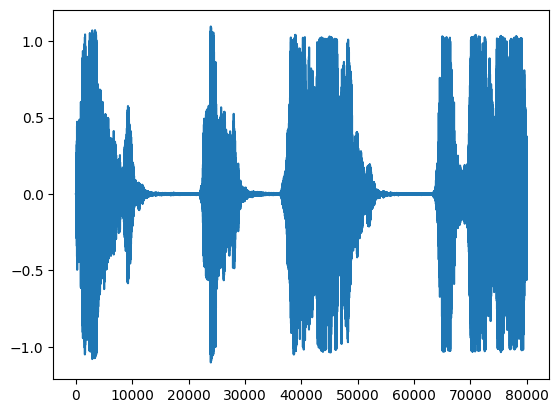

In [ ]:
test_pd = filtered_pd.loc[filtered_pd['fold'] == 5]
row = test_pd.sample(1)
filename = row['filename'].item()
print(filename)
waveform = load_wav_16k_mono(filename)
print(f'Waveform values: {waveform}')
_ = plt.plot(waveform)

display.Audio(waveform, rate=16000)

In [ ]:
# Run the model, check the output.
scores, embeddings, spectrogram = yamnet_model(waveform)
class_scores = tf.reduce_mean(scores, axis=0)
top_class = tf.math.argmax(class_scores)
inferred_class = class_names[top_class]
top_score = class_scores[top_class]
print(f'[YAMNet] The main sound is: {inferred_class} ({top_score})')

reloaded_results = reloaded_model(waveform)
your_top_class = tf.math.argmax(reloaded_results)
your_inferred_class = my_classes[your_top_class]
class_probabilities = tf.nn.softmax(reloaded_results, axis=-1)
your_top_score = class_probabilities[your_top_class]
print(f'[Your model] The main sound is: {your_inferred_class} ({your_top_score})')

[YAMNet] The main sound is: Domestic animals, pets (0.5051151514053345)
[Your model] The main sound is: cat (0.996594250202179)


## Next steps

You have created a model that can classify sounds from dogs or cats. With the same idea and a different dataset you can try, for example, building an [acoustic identifier of birds](https://www.kaggle.com/c/birdclef-2021/) based on their singing.

Share your project with the TensorFlow team on social media!
